In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cleaned_file_path = "../data/processed/telco_customer_churn_cleaned.csv"

df = pd.read_csv(cleaned_file_path)

In [4]:
df.shape

(7043, 36)

In [5]:
df.head()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,tenure_group,monthly_charge_group,cltv_group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-12 Months,Medium Monthly Charge,Low CLTV
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,70.70,151.65,Yes,1,67,2701,Moved,0-12 Months,High Monthly Charge,Low CLTV
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,99.65,820.50,Yes,1,86,5372,Moved,0-12 Months,High Monthly Charge,High CLTV
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,104.80,3046.05,Yes,1,84,5003,Moved,25-48 Months,High Monthly Charge,Medium CLTV
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,103.70,5036.30,Yes,1,89,5340,Competitor had better devices,49-72 Months,High Monthly Charge,High CLTV


In [6]:
df.columns.tolist()

['customerid',
 'count',
 'country',
 'state',
 'city',
 'zip_code',
 'lat_long',
 'latitude',
 'longitude',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_value',
 'churn_score',
 'cltv',
 'churn_reason',
 'tenure_group',
 'monthly_charge_group',
 'cltv_group']

In [7]:
df['churn_value'].value_counts(normalize=True)*100

churn_value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [8]:
overall_churn_rate = df['churn_value'].mean() * 100
overall_churn_rate

np.float64(26.536987079369588)

In [9]:
round(overall_churn_rate, 2)

np.float64(26.54)

In [10]:
total_customers = len(df)
churned_customers = df["churn_value"].sum()
retained_customers = total_customers - churned_customers
overall_churn_rate = df["churn_value"].mean() * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Overall Churn Rate:", round(overall_churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Overall Churn Rate: 26.54 %


In [11]:
df["monthly_charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

In [12]:
total_monthly_revenue = df["monthly_charges"].sum()
total_monthly_revenue

np.float64(456116.6)

In [13]:
churned_monthly_revenue = df[df["churn_value"] == 1]["monthly_charges"].sum()
churned_monthly_revenue

np.float64(139130.85)

In [14]:
retained_monthly_revenue = df[df["churn_value"] == 0]["monthly_charges"].sum()
retained_monthly_revenue

np.float64(316985.75)

In [15]:
revenue_churn_share = (churned_monthly_revenue / total_monthly_revenue) * 100

revenue_churn_share

np.float64(30.503351555282137)

In [16]:
print("Total Monthly Revenue: $", round(total_monthly_revenue, 2))
print("Churned Customer Monthly Revenue: $", round(churned_monthly_revenue, 2))
print("Retained Customer Monthly Revenue: $", round(retained_monthly_revenue, 2))
print("Revenue Churn Share:", round(revenue_churn_share, 2), "%")

Total Monthly Revenue: $ 456116.6
Churned Customer Monthly Revenue: $ 139130.85
Retained Customer Monthly Revenue: $ 316985.75
Revenue Churn Share: 30.5 %


In [17]:
revenue_kpis_formatted = pd.DataFrame({
    "Metric": [
        "Total Monthly Revenue",
        "Churned Customer Monthly Revenue",
        "Retained Customer Monthly Revenue",
        "Revenue Churn Share"
    ],
    "Value": [
        f"${total_monthly_revenue:,.2f}",
        f"${churned_monthly_revenue:,.2f}",
        f"${retained_monthly_revenue:,.2f}",
        f"{revenue_churn_share:.2f}%"
    ]
})

revenue_kpis_formatted

,Metric,Value
0,Total Monthly Revenue,"$456,116.60"
1,Churned Customer Monthly Revenue,"$139,130.85"
2,Retained Customer Monthly Revenue,"$316,985.75"
3,Revenue Churn Share,30.50%


## Revenue Impact of Churn

The customer churn rate is 26.54%, meaning about one in four customers left the company.

However, churned customers represented $139,130.85 out of $456,116.60 in total monthly revenue, or 30.50% of monthly revenue. This means churned customers accounted for a larger share of revenue than their share of the customer base.

This suggests churn is not only a customer retention issue but also a meaningful recurring revenue risk. The company should investigate which high-revenue customer segments are leaving and prioritize retention strategies for those groups.

In [18]:
df.groupby("churn_label")["monthly_charges"].mean()

churn_label
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64

In [19]:
avg_monthly_charge_by_churn = (
    df.groupby("churn_label")["monthly_charges"]
    .mean()
    .reset_index()
)

avg_monthly_charge_by_churn

,churn_label,monthly_charges
0,No,61.265124
1,Yes,74.441332


In [20]:
avg_monthly_charge_by_churn["monthly_charges"] = avg_monthly_charge_by_churn["monthly_charges"].round(2)

avg_monthly_charge_by_churn

,churn_label,monthly_charges
0,No,61.27
1,Yes,74.44


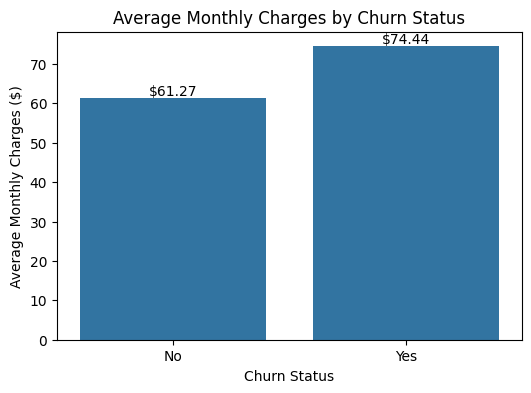

In [21]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=avg_monthly_charge_by_churn,
    x="churn_label",
    y="monthly_charges"
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges ($)")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.2f")

plt.show()

In [22]:
df["contract"].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [23]:
churn_by_contract = (
    df.groupby("contract")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churn_value", "sum"),
        churn_rate = ("churn_value", "mean"),
        avg_monthly_charges = ("monthly_charges", "mean")
    )
    .reset_index()
)
churn_by_contract

,contract,customers,churned_customers,churn_rate,avg_monthly_charges
0,Month-to-month,3875,1655,0.427097,66.398490
1,One year,1473,166,0.112695,65.048608
2,Two year,1695,48,0.028319,60.770413


In [24]:
churn_by_contract["churn_rate"] = churn_by_contract["churn_rate"] * 100
churn_by_contract["churn_rate"] = churn_by_contract["churn_rate"].round(2)
churn_by_contract["avg_monthly_charges"] = churn_by_contract["avg_monthly_charges"].round(2)

churn_by_contract

,contract,customers,churned_customers,churn_rate,avg_monthly_charges
0,Month-to-month,3875,1655,42.71,66.40
1,One year,1473,166,11.27,65.05
2,Two year,1695,48,2.83,60.77


In [25]:
churn_by_contract = churn_by_contract.sort_values("churn_rate", ascending=False)

churn_by_contract

,contract,customers,churned_customers,churn_rate,avg_monthly_charges
0,Month-to-month,3875,1655,42.71,66.40
1,One year,1473,166,11.27,65.05
2,Two year,1695,48,2.83,60.77


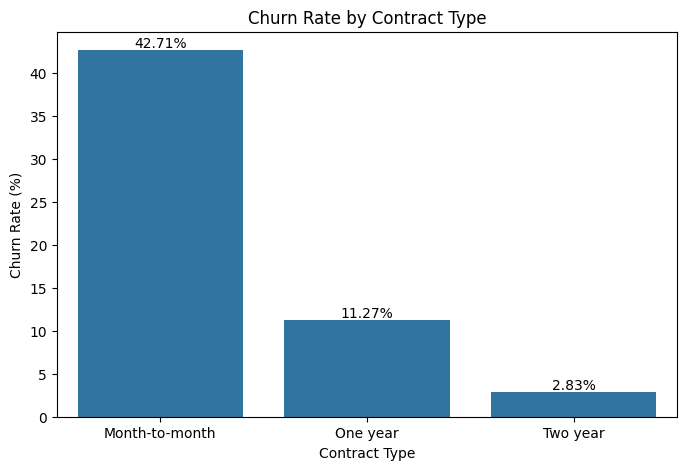

In [26]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_by_contract,
    x="contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

## Churn Rate by Contract Type

Churn rate varies significantly by contract type. Month-to-month customers had the highest churn rate, while longer-term contract customers had much lower churn rates.

This suggests that customers without longer-term commitments are more likely to leave. From a business perspective, the company could reduce churn by encouraging month-to-month customers to move into one-year or two-year contracts through targeted incentives, loyalty discounts, or bundled service offers.

In [27]:
df["tenure_group"].value_counts().sort_index()

tenure_group
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64

In [28]:
churn_by_tenure = (
    df.groupby("tenure_group")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churn_value", "sum"),
        churn_rate=("churn_value", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        avg_cltv=("cltv", "mean")
    )
    .reset_index()
)

churn_by_tenure

,tenure_group,customers,churned_customers,churn_rate,avg_monthly_charges,avg_cltv
0,0-12 Months,2186,1037,0.474382,56.097781,4036.287283
1,13-24 Months,1024,294,0.287109,61.357275,4015.195312
2,25-48 Months,1594,325,0.203890,65.930552,3991.463614
3,49-72 Months,2239,213,0.095132,73.945377,5222.870031


In [29]:
churn_by_tenure["churn_rate"] = churn_by_tenure["churn_rate"] * 100
churn_by_tenure["churn_rate"] = churn_by_tenure["churn_rate"].round(2)
churn_by_tenure["avg_monthly_charges"] = churn_by_tenure["avg_monthly_charges"].round(2)
churn_by_tenure["avg_cltv"] = churn_by_tenure["avg_cltv"].round(2)

churn_by_tenure

,tenure_group,customers,churned_customers,churn_rate,avg_monthly_charges,avg_cltv
0,0-12 Months,2186,1037,47.44,56.10,4036.29
1,13-24 Months,1024,294,28.71,61.36,4015.20
2,25-48 Months,1594,325,20.39,65.93,3991.46
3,49-72 Months,2239,213,9.51,73.95,5222.87


## Churn Rate by Tenure Group

Churn rate is highest among newer customers. Customers with 0-12 months of tenure had a churn rate of 47.77%, compared with 28.71% for 13-24 months, 20.39% for 25-48 months, and 9.51% for 49-72 months.

This suggests that retention risk is highest early in the customer lifecycle. From a business perspective, the company should focus on improving onboarding, first-year customer support, early engagement campaigns, and incentives that encourage new customers to stay past the first year.

In [62]:
charge_group_order = [
    "Low Monthly Charge",
    "Medium Monthly Charge",
    "High Monthly Charge"
]

In [64]:
churn_by_monthly_charge["monthly_charge_group"] = pd.Categorical(
    churn_by_monthly_charge["monthly_charge_group"],
    categories=charge_group_order,
    ordered=True
)

churn_by_monthly_charge = churn_by_monthly_charge.sort_values("monthly_charge_group")

churn_by_monthly_charge

,monthly_charge_group,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue,churn_rate_pct
1,Low Monthly Charge,1735,189,0.108934,22.03,38217.15,10.89
2,Medium Monthly Charge,1725,413,0.239420,54.84,94597.15,23.94
0,High Monthly Charge,3583,1267,0.353614,90.23,323302.30,35.36


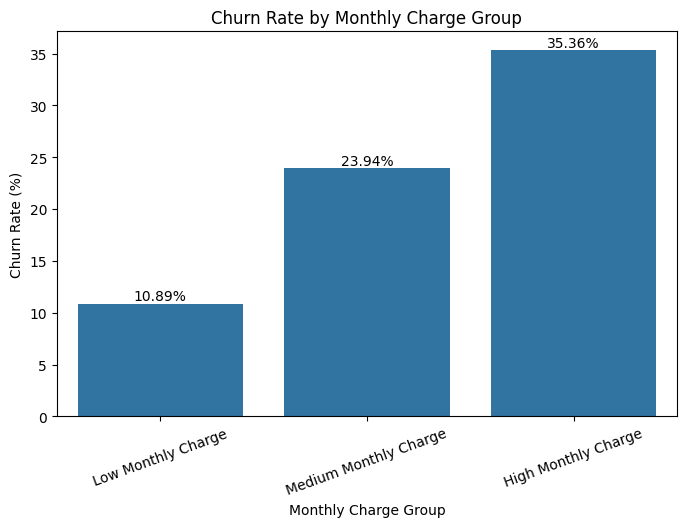

In [65]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_by_monthly_charge,
    x="monthly_charge_group",
    y="churn_rate_pct",
    order=charge_group_order
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.xticks(rotation=20)
plt.show()

## Churn Rate by Monthly Charge Group

Churn rate differs by monthly charge level. Low monthly charge customers had the highest churn rate at 35.56%, followed by high monthly charge customers at 23.94% and medium monthly charge customers at 10.89%.

This suggests that churn risk is not only concentrated among high-paying customers. Lower monthly charge customers leave at the highest rate, while high monthly charge customers still represent important revenue risk because each lost customer contributes more monthly revenue.

From a business perspective, the company should investigate why low-charge customers are leaving at a higher rate while also monitoring high-charge customer churn because of its financial impact.

In [66]:
df["internet_service"].value_counts()

internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [68]:
churn_by_internet_service = (
    df.groupby("internet_service")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churn_value", "sum"),
        churn_rate=("churn_value", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        total_monthly_revenue=("monthly_charges", "sum")
    )
    .reset_index()
)

churn_by_internet_service

,internet_service,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue
0,DSL,2421,459,0.189591,58.102169,140665.35
1,Fiber optic,3096,1297,0.418928,91.500129,283284.40
2,No,1526,113,0.074050,21.079194,32166.85


In [69]:
churn_by_internet_service["churn_rate"] = churn_by_internet_service["churn_rate"] * 100
churn_by_internet_service["churn_rate"] = churn_by_internet_service["churn_rate"].round(2)
churn_by_internet_service["avg_monthly_charges"] = churn_by_internet_service["avg_monthly_charges"].round(2)
churn_by_internet_service["total_monthly_revenue"] = churn_by_internet_service["total_monthly_revenue"].round(2)

churn_by_internet_service

,internet_service,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue
0,DSL,2421,459,18.96,58.10,140665.35
1,Fiber optic,3096,1297,41.89,91.50,283284.40
2,No,1526,113,7.40,21.08,32166.85


In [70]:
churn_by_internet_service = churn_by_internet_service.sort_values("churn_rate", ascending=False)

churn_by_internet_service

,internet_service,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue
1,Fiber optic,3096,1297,41.89,91.50,283284.40
0,DSL,2421,459,18.96,58.10,140665.35
2,No,1526,113,7.40,21.08,32166.85


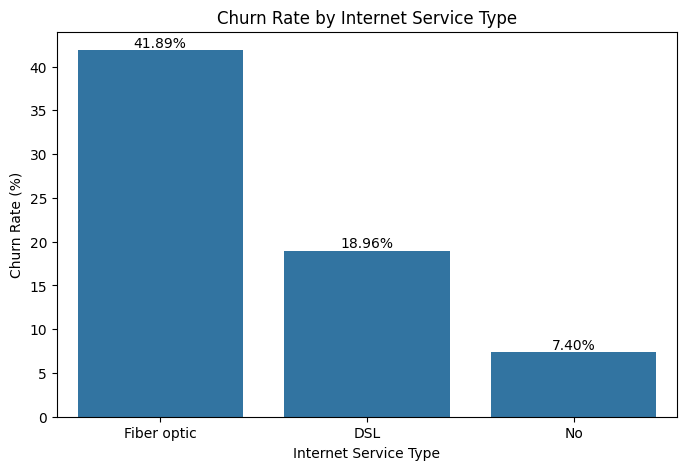

In [71]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_by_internet_service,
    x="internet_service",
    y="churn_rate"
)

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

## Churn Rate by Internet Service Type

Churn rate differs significantly by internet service type. Fiber optic customers had the highest churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers with no internet service.

This suggests that fiber optic customers are a high-risk segment for churn. Since fiber customers may also have higher monthly charges, this segment could represent both a retention issue and a revenue risk.

From a business perspective, the company should investigate fiber optic pricing, service reliability, customer support issues, competitor offers, and whether fiber customers feel they are receiving enough value for their monthly cost.

In [72]:
df["payment_method"].value_counts()

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [74]:
churn_by_payment = (
    df.groupby("payment_method")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churn_value", "sum"),
        churn_rate=("churn_value", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        total_monthly_revenue=("monthly_charges", "sum")
    )
    .reset_index()
)

churn_by_payment

,payment_method,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue
0,Bank transfer (automatic),1544,258,0.167098,67.192649,103745.45
1,Credit card (automatic),1522,232,0.152431,66.512385,101231.85
2,Electronic check,2365,1071,0.452854,76.255814,180345.00
3,Mailed check,1612,308,0.191067,43.917060,70794.30


In [75]:
churn_by_payment["churn_rate_pct"] = (churn_by_payment["churn_rate"] * 100).round(2)
churn_by_payment["avg_monthly_charges"] = churn_by_payment["avg_monthly_charges"].round(2)
churn_by_payment["total_monthly_revenue"] = churn_by_payment["total_monthly_revenue"].round(2)

churn_by_payment = churn_by_payment.sort_values("churn_rate_pct", ascending=False)

churn_by_payment

,payment_method,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue,churn_rate_pct
2,Electronic check,2365,1071,0.452854,76.26,180345.00,45.29
3,Mailed check,1612,308,0.191067,43.92,70794.30,19.11
0,Bank transfer (automatic),1544,258,0.167098,67.19,103745.45,16.71
1,Credit card (automatic),1522,232,0.152431,66.51,101231.85,15.24


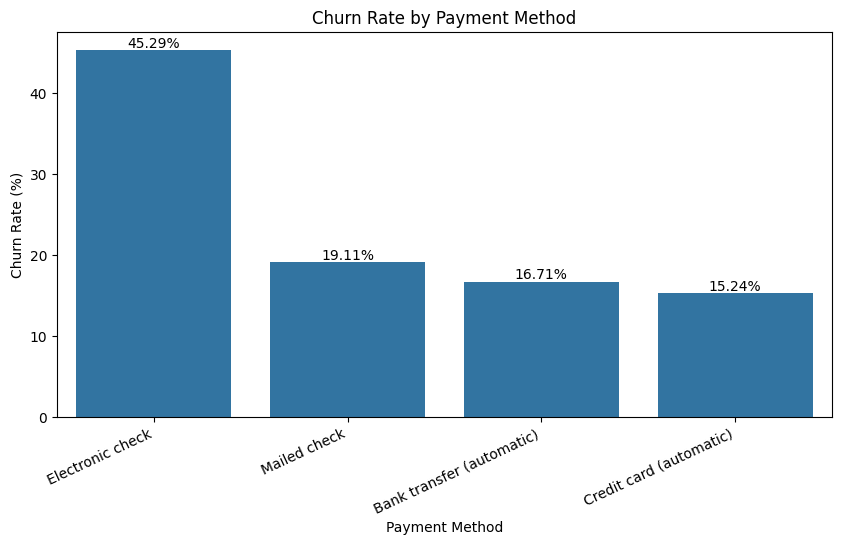

In [76]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=churn_by_payment,
    x="payment_method",
    y="churn_rate_pct"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.xticks(rotation=25, ha="right")
plt.show()

## Churn Rate by Payment Method

Churn rate differs significantly by payment method. Customers using electronic check had the highest churn rate at 45.29%, compared with 19.11% for mailed check, 16.71% for bank transfer automatic, and 15.24% for credit card automatic.

This suggests payment method may be related to customer retention risk. Customers using automatic payment methods had lower churn rates, while electronic check customers were the highest-risk group.

From a business perspective, the company could encourage electronic check customers to switch to automatic payment methods through billing reminders, autopay discounts, or improved payment experience messaging.

In [77]:
churned_customers_df = df[df["churn_value"] == 1]

churned_customers_df.shape

(1869, 36)

In [79]:
churn_reason_counts = (
    churned_customers_df["churn_reason"]
    .value_counts()
    .reset_index()
)

churn_reason_counts.columns = ["churn_reason", "customers"]

churn_reason_counts

,churn_reason,customers
0,Attitude of support person,192
1,Competitor offered higher download speeds,189
2,Competitor offered more data,162
3,Don't know,154
4,Competitor made better offer,140
5,Attitude of service provider,135
6,Competitor had better devices,130
7,Network reliability,103
8,Product dissatisfaction,102
9,Price too high,98


In [80]:
top_churn_reasons = churn_reason_counts.head(10)

top_churn_reasons

,churn_reason,customers
0,Attitude of support person,192
1,Competitor offered higher download speeds,189
2,Competitor offered more data,162
3,Don't know,154
4,Competitor made better offer,140
5,Attitude of service provider,135
6,Competitor had better devices,130
7,Network reliability,103
8,Product dissatisfaction,102
9,Price too high,98


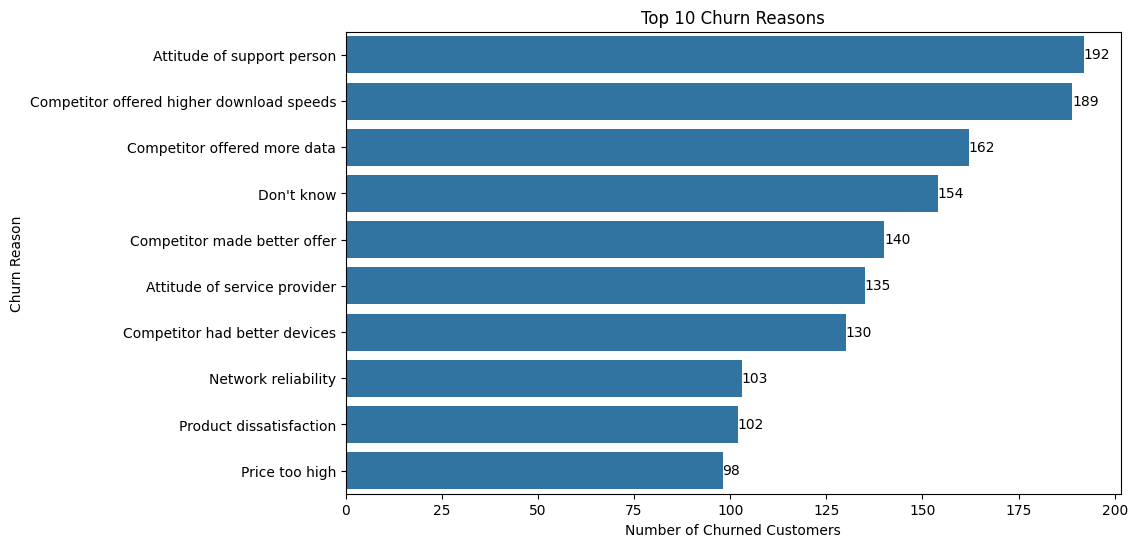

In [81]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_churn_reasons,
    x="customers",
    y="churn_reason"
)

plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Churned Customers")
plt.ylabel("Churn Reason")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [82]:
churn_reason_counts["percent_of_churned_customers"] = (
    churn_reason_counts["customers"] / churned_customers_df.shape[0] * 100
).round(2)

churn_reason_counts.head(10)

,churn_reason,customers,percent_of_churned_customers
0,Attitude of support person,192,10.27
1,Competitor offered higher download speeds,189,10.11
2,Competitor offered more data,162,8.67
3,Don't know,154,8.24
4,Competitor made better offer,140,7.49
5,Attitude of service provider,135,7.22
6,Competitor had better devices,130,6.96
7,Network reliability,103,5.51
8,Product dissatisfaction,102,5.46
9,Price too high,98,5.24


## Top Churn Reasons

The most common churn reasons were attitude of support person, competitor offered higher download speeds, competitor offered more data, don't know, and competitor made better offer.

These reasons suggest that churn is driven by both customer experience issues and competitive pressure. Support-related churn indicates that customer service quality may be affecting retention, while competitor-related reasons suggest that customers may be leaving for better speed, more data, or stronger offers.

From a business perspective, the company should prioritize improving support interactions and monitoring competitor pricing, data plans, and speed offerings. Retention campaigns should focus especially on customers who are high-value, newer, month-to-month, fiber optic, or electronic check customers.

In [83]:
df["high_risk_segment"] = np.where(
    (df["contract"] == "Month-to-month") &
    (df["internet_service"] == "Fiber optic") &
    (df["payment_method"] == "Electronic check"),
    "High Risk",
    "Other Customers"
)

In [84]:
df["high_risk_segment"].value_counts()

high_risk_segment
Other Customers    5736
High Risk          1307
Name: count, dtype: int64

In [86]:
high_risk_summary = (
    df.groupby("high_risk_segment")
    .agg(
        customers=("customerid", "count"),
        churned_customers=("churn_value", "sum"),
        churn_rate=("churn_value", "mean"),
        avg_monthly_charges=("monthly_charges", "mean"),
        total_monthly_revenue=("monthly_charges", "sum"),
        avg_cltv=("cltv", "mean")
    )
    .reset_index()
)

high_risk_summary["churn_rate_pct"] = (high_risk_summary["churn_rate"] * 100).round(2)
high_risk_summary["avg_monthly_charges"] = high_risk_summary["avg_monthly_charges"].round(2)
high_risk_summary["total_monthly_revenue"] = high_risk_summary["total_monthly_revenue"].round(2)
high_risk_summary["avg_cltv"] = high_risk_summary["avg_cltv"].round(2)

high_risk_summary

,high_risk_segment,customers,churned_customers,churn_rate,avg_monthly_charges,total_monthly_revenue,avg_cltv,churn_rate_pct
0,High Risk,1307,789,0.603673,87.18,113948.1,4132.04,60.37
1,Other Customers,5736,1080,0.188285,59.65,342168.5,4461.42,18.83


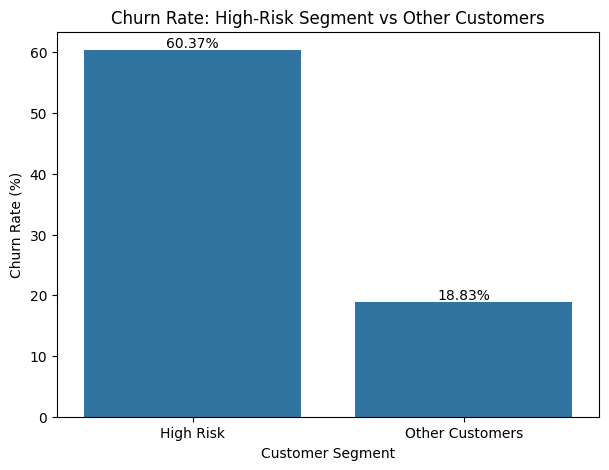

In [87]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=high_risk_summary,
    x="high_risk_segment",
    y="churn_rate_pct"
)

plt.title("Churn Rate: High-Risk Segment vs Other Customers")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

## High-Risk Customer Segment

I created a high-risk customer segment made up of customers with month-to-month contracts, fiber optic internet service, and electronic check payment method. These characteristics were selected because each was associated with high churn rates in the earlier analysis.

The high-risk segment contained 1,307 customers and had a churn rate of 60.37%, compared with 18.83% for other customers. This suggests that churn risk compounds when multiple high-risk characteristics appear together.

From a business perspective, this segment should be prioritized for targeted retention campaigns, improved support outreach, billing experience improvements, and offers that encourage longer-term contracts or automatic payment methods.

In [88]:
summary_metrics = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Overall Churn Rate",
        "Total Monthly Revenue",
        "Churned Customer Monthly Revenue",
        "Revenue Churn Share",
        "Avg Monthly Charge - Retained Customers",
        "Avg Monthly Charge - Churned Customers",
        "High-Risk Segment Customers",
        "High-Risk Segment Churn Rate",
        "Other Customers Churn Rate"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['churn_value'].mean() * 100:.2f}%",
        f"${df['monthly_charges'].sum():,.2f}",
        f"${df[df['churn_value'] == 1]['monthly_charges'].sum():,.2f}",
        f"{(df[df['churn_value'] == 1]['monthly_charges'].sum() / df['monthly_charges'].sum()) * 100:.2f}%",
        f"${df[df['churn_value'] == 0]['monthly_charges'].mean():,.2f}",
        f"${df[df['churn_value'] == 1]['monthly_charges'].mean():,.2f}",
        f"{df[df['high_risk_segment'] == 'High Risk'].shape[0]:,}",
        f"{df[df['high_risk_segment'] == 'High Risk']['churn_value'].mean() * 100:.2f}%",
        f"{df[df['high_risk_segment'] == 'Other Customers']['churn_value'].mean() * 100:.2f}%"
    ]
})

summary_metrics

,Metric,Value
0,Total Customers,"7,043"
1,Overall Churn Rate,26.54%
2,Total Monthly Revenue,"$456,116.60"
3,Churned Customer Monthly Revenue,"$139,130.85"
4,Revenue Churn Share,30.50%
5,Avg Monthly Charge - Retained Customers,$61.27
6,Avg Monthly Charge - Churned Customers,$74.44
7,High-Risk Segment Customers,"1,307"
8,High-Risk Segment Churn Rate,60.37%
9,Other Customers Churn Rate,18.83%


In [89]:
summary_metrics.to_csv("../reports/eda_summary_metrics.csv", index=False)

## Exploratory Analysis Summary

The exploratory analysis identified several important churn and revenue patterns:

- Overall churn rate was 26.54%.
- Churned customers represented 30.50% of total monthly revenue.
- Churned customers had higher average monthly charges than retained customers.
- Month-to-month contracts, fiber optic internet service, and electronic check payment were associated with higher churn.
- Newer customers had much higher churn rates than long-term customers.
- The combined high-risk segment of month-to-month, fiber optic, and electronic check customers had a churn rate of 60.37%, compared with 18.83% for other customers.

These findings suggest that churn is both a customer retention issue and a revenue risk. The company should prioritize retention strategies for newer customers, high monthly charge customers, fiber optic customers, electronic check customers, and customers with multiple high-risk characteristics.